In [1]:
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
import scipy
from matplotlib import pyplot as plt

In [2]:
DATASET_DIR = Path(r"")
IMU_ID = 1
MAG_FILENAME = f"mag_{IMU_ID:03d}.csv"
MAG_FILE = DATASET_DIR / MAG_FILENAME


In [3]:
def parse_csv(f: Path) -> np.ndarray:
    """
    读取CSV,返回磁力计数据。
    """
    data = np.genfromtxt(f, delimiter=',', skip_header=1, usecols=(1, 2, 3))
    return data.T

In [4]:
data = parse_csv(MAG_FILE)
print(data)

[[ 0.01464844 -0.03027344 -0.06542969 ... -0.03222656 -0.06152344
  -0.11035156]
 [-0.12597656 -0.04199219  0.04785156 ... -0.48535156 -0.42382812
  -0.11035156]
 [ 0.39160156  0.41015625  0.40527344 ... -0.04296875 -0.24023438
  -0.4345703 ]]


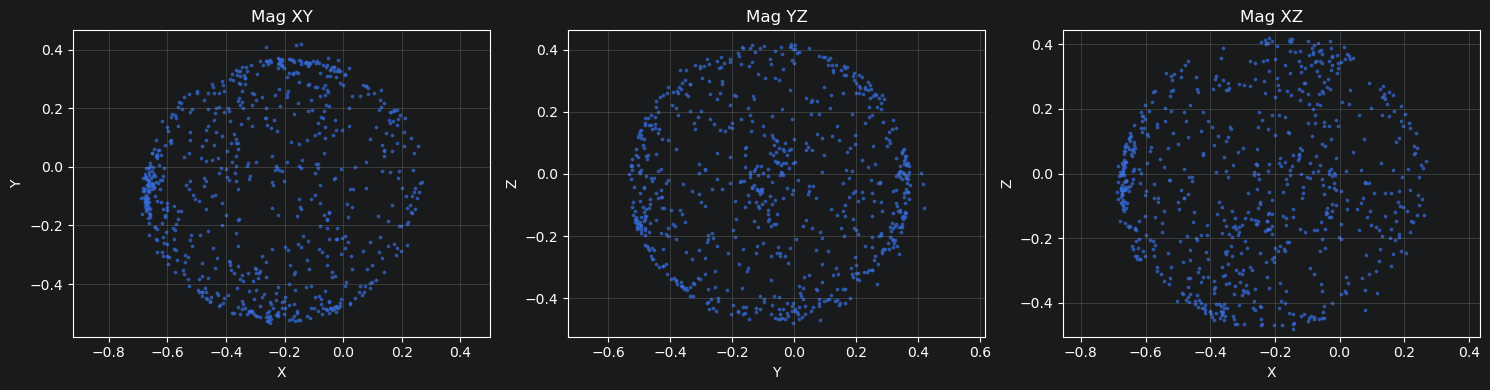

In [5]:
mx, my, mz = data

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(mx, my, s=3, alpha=0.6)
axes[0].set_title('Mag XY')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].axis('equal')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(my, mz, s=3, alpha=0.6)
axes[1].set_title('Mag YZ')
axes[1].set_xlabel('Y')
axes[1].set_ylabel('Z')
axes[1].axis('equal')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(mx, mz, s=3, alpha=0.6)
axes[2].set_title('Mag XZ')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Z')
axes[2].axis('equal')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
mx, my, mz = data

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=mx,
            y=my,
            z=mz,
            mode='markers',
            marker=dict(size=2, opacity=0.7)
        )
    ]
)

fig.update_layout(
    title='Mag 3D Point Cloud',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    )
)

fig.show()

In [7]:
def magneto_get_submatrices(ata):
    s11 = ata[:6, :6]
    s12 = ata[:6, 6:10]
    s22 = ata[6:10, 6:10]
    return s11, s12, s22


def magneto_get_constraint_matrices():
    # 原 C 代码里这里使用的是预先求逆后的约束矩阵 C_inv
    c_inv = np.array([
        [0.0, 0.5, 0.5, 0.0, 0.0, 0.0],
        [0.5, 0.0, 0.5, 0.0, 0.0, 0.0],
        [0.5, 0.5, 0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, -0.25, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, -0.25, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, -0.25],
    ], dtype=np.float64)

    # 真正的椭球约束矩阵 C，满足 SS v = lambda C v
    c = np.array([
        [-1.0, 1.0, 1.0, 0.0, 0.0, 0.0],
        [1.0, -1.0, 1.0, 0.0, 0.0, 0.0],
        [1.0, 1.0, -1.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, -4.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, -4.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, -4.0],
    ], dtype=np.float64)
    return c_inv, c


def magneto_get_v1(ss, c_inv):
    # v1: 二次项系数
    eigenvalues, eigenvectors = scipy.linalg.eig(c_inv @ ss)
    index = np.argmax(eigenvalues.real)
    v1 = eigenvectors[:, index].real
    v1 = v1 / np.linalg.norm(v1)
    if v1[0] < 0.0:
        v1 = -v1
    return v1


def magneto_get_q_u_j(v1, v2):
    # v1: 二次项系数
    # v2: 线性项+常数项系数
    q = v1[np.array([
        [0, 5, 4],
        [5, 1, 3],
        [4, 3, 2],
    ])].astype(np.float64)
    u = v2[:3].astype(np.float64)
    j = v2[-1]
    return q, u, j


def magneto_get_result(q, u, j, mean_norm):
    # 椭圆方程改写成 (x - b)ᵀ Q (x - b) = bᵀ Q b - J
    # 椭圆中心满足Qb = -u
    b = np.linalg.solve(q, u)
    eigenvalues, eigenvectors = np.linalg.eigh(q)
    sq = eigenvectors @ np.diag(np.sqrt(eigenvalues)) @ eigenvectors.T

    radius = np.sqrt(b @ q @ b - j)
    k = sq * mean_norm / radius
    return b, k


def magneto_preprocess_data(data: np.ndarray):
    x, y, z = data
    # d: 椭球方程的10项，后续的v = [a b c d e f g h i j]
    # v · d = 椭球方程 xᵀ Q x + 2 uᵀ x + J = 0
    d = np.vstack([
        x * x,
        y * y,
        z * z,
        2.0 * y * z,
        2.0 * x * z,
        2.0 * x * y,
        2.0 * x,
        2.0 * y,
        2.0 * z,
        np.ones_like(x),
    ]).astype(np.float64)

    ata = d @ d.T
    mean_norm = np.linalg.norm(data, axis=0).mean()
    return ata, mean_norm


def magneto_get_calibration(data: np.ndarray):
    # 拟合椭球方程
    # xᵀ Q x + 2 uᵀ x + J = 0
    ata, mean_norm = magneto_preprocess_data(data)
    s11, s12, s22 = magneto_get_submatrices(ata)

    # 消元，先求二次项系数
    s22a = np.linalg.inv(s22) @ s12.T
    ss = s11 - s12 @ s22a

    c_inv, c = magneto_get_constraint_matrices()
    v1 = magneto_get_v1(ss, c_inv)
    v2 = -(s22a @ v1)
    # 用二次项结果解线性项
    q, u, j = magneto_get_q_u_j(v1, v2)
    return magneto_get_result(q, u, j, mean_norm)

In [8]:
b, k = magneto_get_calibration(data)
print(b)
print(k)

[0.20542766 0.07748575 0.02739028]
[[ 1.10241063 -0.01087419 -0.00264148]
 [-0.01087419  1.15205053  0.00511887]
 [-0.00264148  0.00511887  1.15516497]]


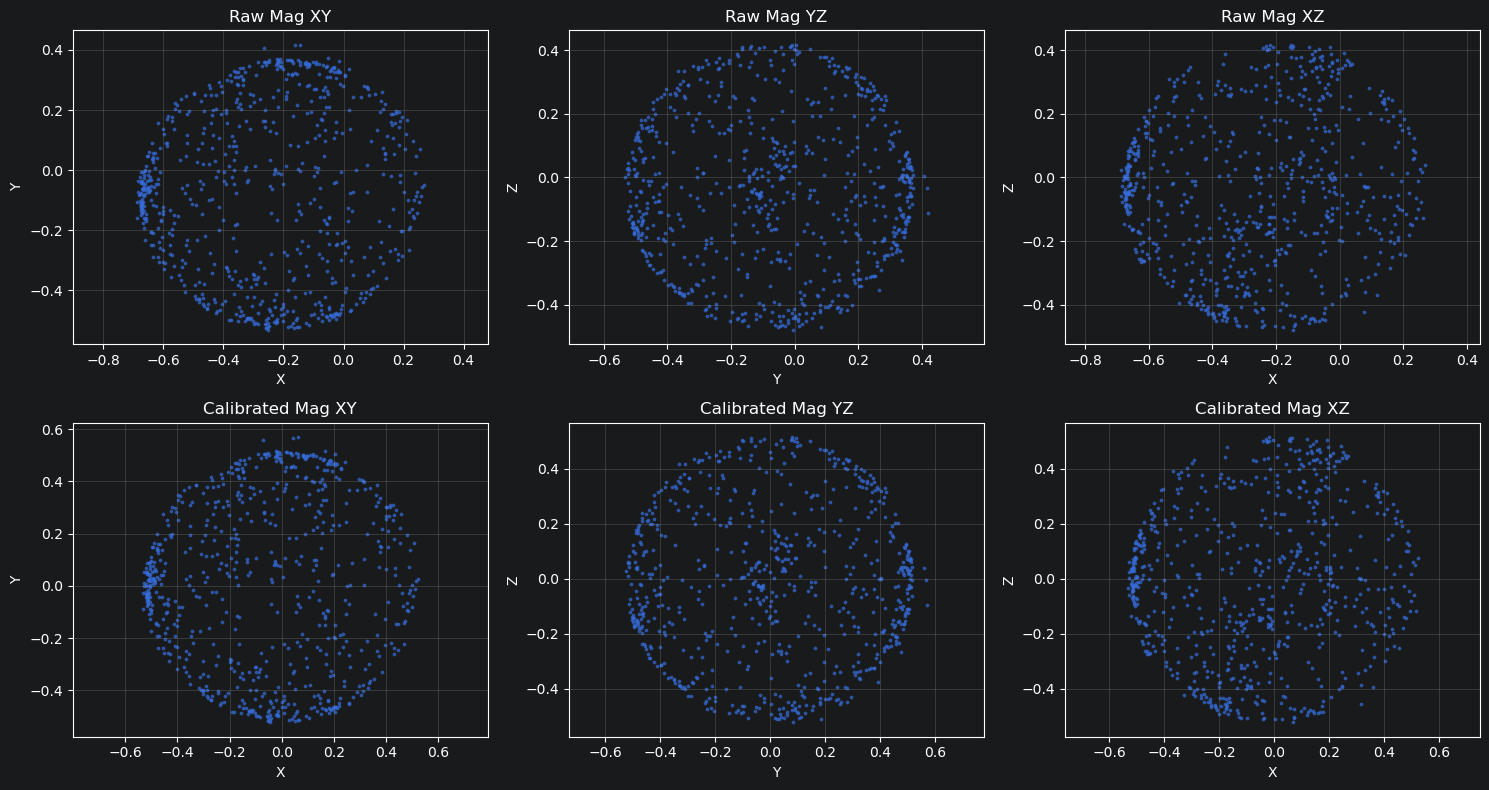

In [9]:
calibrated_data = k @ (data + b[:, None])
mx, my, mz = data
cx, cy, cz = calibrated_data

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].scatter(mx, my, s=3, alpha=0.6)
axes[0, 0].set_title('Raw Mag XY')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Y')
axes[0, 0].axis('equal')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(my, mz, s=3, alpha=0.6)
axes[0, 1].set_title('Raw Mag YZ')
axes[0, 1].set_xlabel('Y')
axes[0, 1].set_ylabel('Z')
axes[0, 1].axis('equal')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].scatter(mx, mz, s=3, alpha=0.6)
axes[0, 2].set_title('Raw Mag XZ')
axes[0, 2].set_xlabel('X')
axes[0, 2].set_ylabel('Z')
axes[0, 2].axis('equal')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].scatter(cx, cy, s=3, alpha=0.6)
axes[1, 0].set_title('Calibrated Mag XY')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')
axes[1, 0].axis('equal')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(cy, cz, s=3, alpha=0.6)
axes[1, 1].set_title('Calibrated Mag YZ')
axes[1, 1].set_xlabel('Y')
axes[1, 1].set_ylabel('Z')
axes[1, 1].axis('equal')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].scatter(cx, cz, s=3, alpha=0.6)
axes[1, 2].set_title('Calibrated Mag XZ')
axes[1, 2].set_xlabel('X')
axes[1, 2].set_ylabel('Z')
axes[1, 2].axis('equal')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=cx,
            y=cy,
            z=cz,
            mode='markers',
            marker=dict(size=2, opacity=0.7)
        )
    ]
)

fig.update_layout(
    title='Calibrated Mag 3D Point Cloud',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    )
)

fig.show()

In [11]:
from scipy.io import savemat

mat_file = DATASET_DIR / f'mag_calibration_{IMU_ID:03d}.mat'
savemat(mat_file, {
    'K': k,
    'b': b.reshape(3, 1),
})
print(mat_file)

mag_calibration_001.mat
